=== Unmatched files (category could not be determined) ===


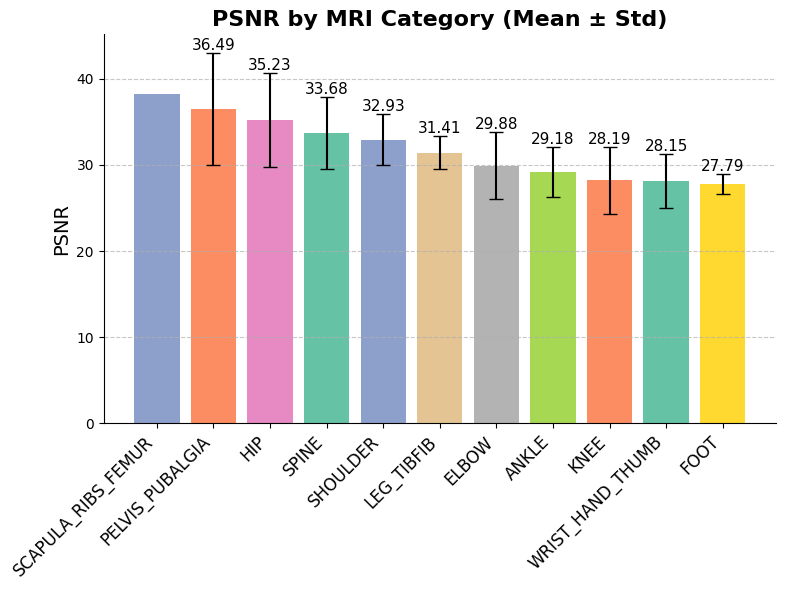

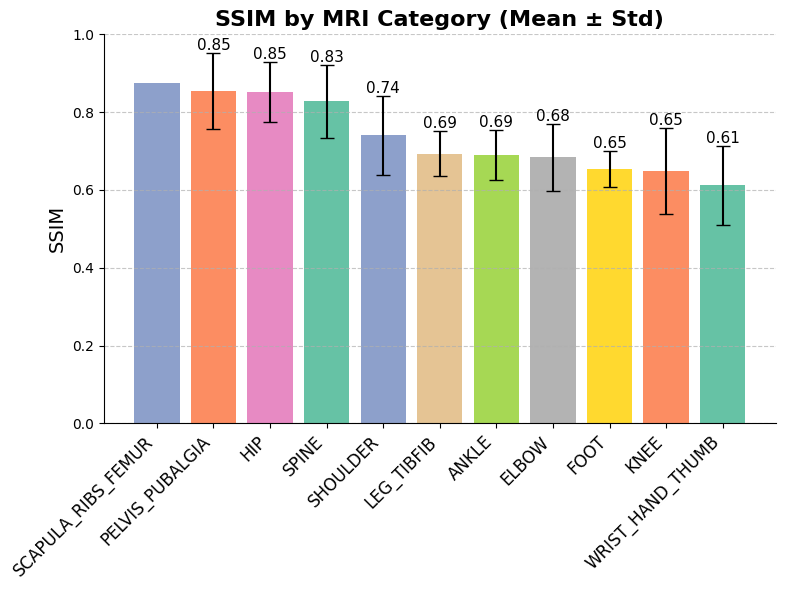

In [7]:
import os, json, h5py, xml.dom.minidom as minidom
from collections import defaultdict, Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- CONFIG: set these ----------
results_path = "./outputs/varnet_inference_test_set_final"
json_path = results_path + "/metrics.json"   # path to your JSON above
data_dir  = "../../../../../data/datasets/msk_mri_h5/varnet_msk_dataset3/multicoil_test"  # folder containing the .h5 files
# --------------------------------------

scan_categories = {
    "SPINE": {"includes": ["L-SPINE","LSPINE","L SPINE","C-SPINE","CSPINE","C SPINE","T-SPINE","T SPINE",
                           "AX T2 T-SP","AX T2 T-SP WARP"]},
    "KNEE": {"includes": ["LT KNEE","RT KNEE"]},
    "SHOULDER": {"includes": ["LT SHOULDER","RT SHOULDER"]},
    "HIP": {"includes": ["LT HIP","RT HIP"]},
    "ANKLE": {"includes": ["LT ANKLE","RT ANKLE"]},
    "FOOT": {"includes": ["LT FOOT","RT FOOT"]},
    "LEG_TIBFIB": {"includes": ["LT LEG","RT TIB-FIB"]},
    "ELBOW": {"includes": ["LT ELBOW","RT ELBOW"]},
    "WRIST_HAND_THUMB": {"includes": ["LT WRIST","RT WRIST","LT THUMB","RT THUMB","RT HAND","WRIST RT"]},
    "PELVIS_PUBALGIA": {"includes": ["PELVIS","ATH PUBALGIA"]},
    "SCAPULA_RIBS_FEMUR": {"includes": ["RT SCAPULA","RIBS","LT FEMUR"]},
}

def parse_header_study_and_patient(h5_path):
    """Return (tStudyDescription, patientID) from ismrmrd_header; None if missing."""
    try:
        with h5py.File(h5_path, "r") as f:
            if "ismrmrd_header" not in f:
                return None, None
            xml_raw = f["ismrmrd_header"][()]
            if isinstance(xml_raw, (bytes, bytearray, np.void)):
                xml_str = bytes(xml_raw).decode(errors="ignore")
            else:
                xml_str = str(xml_raw)
        dom = minidom.parseString(xml_str)
        # generic helper
        def _first_text(parent, tag):
            nodes = parent.getElementsByTagName(tag)
            if nodes and nodes[0].firstChild:
                return nodes[0].firstChild.data.strip()
            return None

        # userParameters may have name/value pairs
        study = None
        ups = dom.getElementsByTagName("userParameterString")
        for node in ups:
            name = _first_text(node, "name")
            if name == "tStudyDescription":
                study = _first_text(node, "value")
                break

        # fallback: try studyInformation/studyDescription (not always present)
        if study is None:
            study = _first_text(dom, "studyDescription")

        # patientID (typical location: subjectInformation/patientID)
        pid = None
        sub = dom.getElementsByTagName("subjectInformation")
        if sub:
            pid = _first_text(sub[0], "patientID")

        return study, pid
    except Exception:
        return None, None

def categorize(study_desc):
    if not study_desc:
        return None
    s = study_desc.upper()
    for cat, info in scan_categories.items():
        for token in info["includes"]:
            if token in s:
                return cat
    return None

# --------- Load JSON ----------
with open(json_path, "r") as f:
    metrics_json = json.load(f)

per_vol = metrics_json.get("per_volume", {})

# --------- Build table ----------
rows = []
unmatched = []
for fname, m in per_vol.items():
    h5_path = os.path.join(data_dir, fname)
    study, pid = parse_header_study_and_patient(h5_path)
    cat = categorize(study)
    if cat is None:
        unmatched.append((fname, study))
    rows.append({
        "file": fname,
        "category": cat,
        "study": study,
        "patientID": pid,
        "PSNR": m.get("PSNR"),
        "SSIM": m.get("SSIM"),
    })

df = pd.DataFrame(rows)

# --------- Print unmatched and patient counts ----------
print("=== Unmatched files (category could not be determined) ===")
for fname, study in unmatched:
    print(f"- {fname} | tStudyDescription={study}")

df_matched = df.dropna(subset=["category"])
# --------- Plots: one figure per metric (bar of mean with std) ----------
import matplotlib.pyplot as plt

# Assign a color to each category for consistent plotting
# Assign a color to each possible category for consistent plotting
all_categories = list(scan_categories.keys())
color_list = plt.cm.Set2.colors
color_map = {cat: color_list[i % len(color_list)] for i, cat in enumerate(all_categories)}

def plot_metric(metric_name):
    g = df_matched.groupby("category")[metric_name]
    means = g.mean().sort_values(ascending=False)
    stds  = g.std().reindex(means.index)

    # Get colors for each category in the order of means.index, fallback to a default if missing
    default_color = "gray"
    bar_colors = [color_map.get(cat, default_color) for cat in means.index]

    plt.figure(figsize=(8, 6))
    bars = plt.bar(range(len(means)), means.values, yerr=stds.values, capsize=5, 
                   color=bar_colors)

    plt.xticks(range(len(means)), means.index, rotation=45, ha='right', fontsize=12)
    plt.ylabel(metric_name, fontsize=14)
    plt.title(f"{metric_name} by MRI Category (Mean ± Std)", fontsize=16, weight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.gca().set_facecolor('white')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    # Add value labels on top of bars
    for bar, mean, std in zip(bars, means.values, stds.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std, 
                 f"{mean:.2f}", ha='center', va='bottom', fontsize=11)

    plt.tight_layout()

for metric in ["PSNR", "SSIM"]:
    plot_metric(metric)

plt.show()

In [5]:
# Display overall average PSNR and SSIM for all matched MRI categories
avg_psnr = df_matched['PSNR'].mean()
avg_ssim = df_matched['SSIM'].mean()
print(f'Overall average PSNR: {avg_psnr:.2f}')
print(f'Overall average SSIM: {avg_ssim:.4f}')

Overall average PSNR: 41.22
Overall average SSIM: 0.9481


In [3]:
low_quality = df_matched[(df_matched['PSNR'] < 25) | (df_matched['SSIM'] < 0.55)]
low_quality.head(50)

,file,category,study,patientID,PSNR,SSIM
27,meas_MID00022_FID135138_SAG_STIR.h5,SPINE,L-SPINE,18.0.261379110,27.371229,0.519233
32,meas_MID00023_FID125149_SAG_T2_FS.h5,KNEE,LT KNEE,18.0.239490086,27.218007,0.497611
41,meas_MID00025_FID110993_COR_T1.h5,KNEE,RT KNEE,18.0.211751974,23.273646,0.522203
42,meas_MID00025_FID112002_COR_T1.h5,KNEE,RT KNEE,18.0.213799974,23.707401,0.520332
48,meas_MID00025_FID125151_COR_T1.h5,KNEE,LT KNEE,18.0.239490086,23.045290,0.503643
49,meas_MID00025_FID127074_AX_PD_FS.h5,SHOULDER,LT SHOULDER,18.0.243078182,26.991745,0.547312
62,meas_MID00028_FID117528_COR_PD_FS.h5,KNEE,RT KNEE,18.0.224711718,24.432706,0.583363
69,meas_MID00029_FID130099_AX_PD_FS.h5,SHOULDER,RT SHOULDER,18.0.249844774,26.058942,0.520612
70,meas_MID00030_FID110463_SAG_STIR.h5,SPINE,L-SPINE,18.0.210965544,28.170428,0.534091
71,meas_MID00030_FID113501_COR_STIR_WP.h5,HIP,LT HIP,18.0.216732710,23.597369,0.733997


# save plots of the files that achieve less than 25 psnr or 0.55 of ssim

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

data_dir = "../../../../../data/datasets/msk_mri_h5/varnet_mrpro"
output_dir = "./outputs/low_quality_pngs"
varnet_png_dir = "./outputs/varnet_inference_mrpro_full_dataset"
os.makedirs(output_dir, exist_ok=True)
MAX_PLOTS = 20
print(f'Saving grid images of up to {MAX_PLOTS} slices from reconstruction_rss for low-quality files to {output_dir}:')

for idx, row in low_quality.iterrows():
    fname = row['file']
    psnr = row['PSNR']
    ssim = row['SSIM']
    category = row['category'] if row['category'] else 'Unknown'
    h5_path = os.path.join(data_dir, fname)
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    try:
        h5_size_mb = os.path.getsize(h5_path) / (1024 * 1024)
        with h5py.File(h5_path, "r") as f:
            if 'reconstruction_rss' not in f:
                print(f"'reconstruction_rss' not found in {fname}")
                continue
            recon = f['reconstruction_rss'][()]
            num_slices = recon.shape[0]
            n_plot = min(MAX_PLOTS, num_slices)
            shape_str = str(recon.shape)

            # --- First: create the grid of slices with its title ---
            grid_fig, grid_axes = plt.subplots(4, 5, figsize=(20, 16))
            grid_fig.suptitle(f"{fname} | {category} | PSNR={psnr:.2f} | SSIM={ssim:.2f} | shape={shape_str} | size={h5_size_mb:.1f}MB", fontsize=18, weight='bold')
            for i in range(n_plot):
                ax = grid_axes[i // 5, i % 5]
                ax.imshow(recon[i], cmap='gray')
                ax.set_title(f"Slice {i}", fontsize=10)
                ax.axis('off')
            for i in range(n_plot, 20):
                ax = grid_axes[i // 5, i % 5]
                ax.axis('off')
            grid_fig.tight_layout(rect=[0, 0.03, 1, 0.95])

            # Save the grid to a temporary PNG
            temp_grid_path = os.path.join(output_dir, "_temp_grid.png")
            grid_fig.savefig(temp_grid_path, bbox_inches='tight', pad_inches=0.1)
            plt.close(grid_fig)

            # --- Second: stack the VarNet output PNG below the grid ---
            png_base = os.path.splitext(os.path.basename(fname))[0]
            png_candidates = [f for f in os.listdir(varnet_png_dir) if png_base in f and f.lower().endswith('.png')]
            if png_candidates:
                varnet_png_path = os.path.join(varnet_png_dir, png_candidates[0])
                try:
                    grid_img = plt.imread(temp_grid_path)
                    varnet_img = plt.imread(varnet_png_path)
                    # Create stacked figure
                    fig, axes = plt.subplots(2, 1, figsize=(20, 24), gridspec_kw={'height_ratios': [4, 1]})
                    axes[0].imshow(grid_img)
                    axes[0].axis('off')
                    axes[1].imshow(varnet_img)
                    axes[1].set_title("VarNet Output", fontsize=16, color='blue')
                    axes[1].axis('off')
                    plt.tight_layout()
                    png_name = f"{category}_{png_base}_grid_with_varnet.png"
                    png_path = os.path.join(output_dir, png_name)
                    plt.savefig(png_path, bbox_inches='tight', pad_inches=0.1)
                    plt.close(fig)
                    print(f"Saved stacked grid image for {fname} ({category}, PSNR={psnr:.2f}, shape={shape_str}, size={h5_size_mb:.1f}MB) with VarNet output")
                except Exception as e:
                    print(f"Error loading PNG {varnet_png_path} or stacking: {e}")
            else:
                # Only save the grid if no VarNet PNG found
                png_name = f"{category}_{png_base}_grid_with_varnet.png"
                png_path = os.path.join(output_dir, png_name)
                os.rename(temp_grid_path, png_path)
                print(f"Saved grid image for {fname} ({category}, PSNR={psnr:.2f}, shape={shape_str}, size={h5_size_mb:.1f}MB) (no VarNet output)")

            # Remove temp grid file if exists
            if os.path.exists(temp_grid_path):
                os.remove(temp_grid_path)
    except Exception as e:
        print(f"Error reading {h5_path}: {e}")

Saving grid images of up to 20 slices from reconstruction_rss for low-quality files to ./outputs/low_quality_pngs:
Saved stacked grid image for meas_MID00022_FID135138_SAG_STIR.h5 (SPINE, PSNR=27.37, shape=(18, 512, 512), size=417.1MB) with VarNet output
Saved stacked grid image for meas_MID00023_FID125149_SAG_T2_FS.h5 (KNEE, PSNR=27.22, shape=(40, 768, 768), size=2427.9MB) with VarNet output
Saved stacked grid image for meas_MID00025_FID110993_COR_T1.h5 (KNEE, PSNR=23.27, shape=(42, 384, 384), size=1441.1MB) with VarNet output
Saved stacked grid image for meas_MID00025_FID112002_COR_T1.h5 (KNEE, PSNR=23.71, shape=(46, 384, 384), size=1578.4MB) with VarNet output
Saved stacked grid image for meas_MID00025_FID125151_COR_T1.h5 (KNEE, PSNR=23.05, shape=(40, 384, 384), size=1372.5MB) with VarNet output
Saved stacked grid image for meas_MID00025_FID127074_AX_PD_FS.h5 (SHOULDER, PSNR=26.99, shape=(30, 640, 640), size=1546.9MB) with VarNet output
Saved stacked grid image for meas_MID00028_FID

# Rename PNGs with scan category prefix

In [8]:
# Rename PNGs in ./outputs/varnet_inference_mrpro_full_dataset with scan category prefix
import os


# Build a mapping from file name to scan category using the DataFrame from previous cells
file_to_category = dict(zip(df['file'], df['category']))

for fname in os.listdir(results_path):
    if fname.lower().endswith('.png'):
        # Try to find the scan category for this PNG
        # Assume PNG filename contains the base file name (without extension) from df['file']
        base_name = fname.split('.h5')[0]
        # Find matching entry in df['file']
        matched = [cat for f, cat in file_to_category.items() if base_name in f]
        if matched and matched[0]:
            prefix = matched[0]
            new_name = f"{prefix}_{fname}"
            src = os.path.join(results_path, fname)
            dst = os.path.join(results_path, new_name)
            os.rename(src, dst)
            print(f"Renamed {fname} -> {new_name}")
        else:
            print(f"No category found for {fname}, skipping.")

Renamed meas_MID00394_FID132587_SAG_STIR.h5_slice5_visualization.png -> ANKLE_meas_MID00394_FID132587_SAG_STIR.h5_slice5_visualization.png
Renamed meas_MID00198_FID132391_SAG_T2.h5_slice5_visualization.png -> SPINE_meas_MID00198_FID132391_SAG_T2.h5_slice5_visualization.png
Renamed meas_MID00051_FID125572_AX_T2_ANGLE_DISC.h5_slice5_visualization.png -> SPINE_meas_MID00051_FID125572_AX_T2_ANGLE_DISC.h5_slice5_visualization.png
Renamed meas_MID00239_FID133884_SAG_T2.h5_slice5_visualization.png -> SPINE_meas_MID00239_FID133884_SAG_T2.h5_slice5_visualization.png
Renamed meas_MID00404_FID121100_SAG_T1.h5_slice5_visualization.png -> SPINE_meas_MID00404_FID121100_SAG_T1.h5_slice5_visualization.png
Renamed meas_MID00029_FID120725_SAG_STIR.h5_slice5_visualization.png -> SPINE_meas_MID00029_FID120725_SAG_STIR.h5_slice5_visualization.png
Renamed meas_MID00397_FID120633_SAG_T2_FS.h5_slice5_visualization.png -> KNEE_meas_MID00397_FID120633_SAG_T2_FS.h5_slice5_visualization.png
Renamed meas_MID00312_